# 2 - ASK Envelope Demod

Liest die in Notebook 1 erzeugte ASK-Wellenform aus
`recordings/ask.json` ein, stellt sie dar und demoduliert sie per
Hüllkurvendemodulation. Anschliessend werden die Bits per Mid-Bit-Sampling
wiedergewonnen und mit der originalen PRBS-15 Sequenz verglichen (BER).

## Prinzip der Hüllkurvendemodulation

Ein klassischer Hüllkurvendetektor besteht aus zwei Schritten:

1. **Gleichrichtung**
   - Aus dem ASK-Signal wird ein nur positiver Verlauf gewonnen (hier:
     Vollweggleichrichtung mit `np.abs`).

2. **Tiefpassfilterung**
   - Die hochfrequenten Trägeranteile werden geglättet, die langsame
     Hüllkurve bleibt.
   - Hier verwenden wir didaktisch einen **Sliding-Averager** (gleitender
     Mittelwert) mit einstellbarer Fensterbreite, vorgegeben über eine
     äquivalente Grenzfrequenz `f_lp`.

Anschliessend trifft eine **Mid-Bit-Entscheidung** über die Schwelle
$U_c$ (mittlere Hüllkurvenhöhe) zwischen den Pegeln $1-m$ und $1+m$.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().resolve()))

import numpy as np
import matplotlib.pyplot as plt

from lib.plot_style import apply_lab_matplotlib_style

apply_lab_matplotlib_style()

## ASK-Recording laden

Liest `recordings/ask.json`. Alle Modulator-Parameter (Abtastrate, Bitrate,
Samples/Bit, Modulationsgrad, Original-Bits) liegen als Metadaten bei und
werden im Folgenden verwendet.

In [2]:
from pathlib import Path

from lib.ask_recording import load_ask_recording_v1

rec_path = Path('recordings/ask.json')
rec = load_ask_recording_v1(rec_path)

fs = rec.fs_hz
f_c = rec.f_carrier_hz
U_c = rec.U_c
m = rec.modulation_index
samples_per_bit = rec.samples_per_bit
R_b = rec.bit_rate_hz
T_b = 1.0 / R_b
n_bits = rec.n_bits
N_sig = rec.n_samples

s_ask = np.asarray(rec.samples, dtype=np.float64)
bits_orig = np.asarray(rec.bits, dtype=np.int8)

t = np.arange(N_sig) / fs

print(f'Geladen: {rec_path} ({N_sig} Samples)')
print(f'  fs = {fs} Hz, f_c = {f_c} Hz, m = {m}')
print(f'  samples_per_bit = {samples_per_bit}, R_b = {R_b:.1f} bit/s, n_bits = {n_bits}')

Geladen: recordings\ask.json (18000 Samples)
  fs = 200000.0 Hz, f_c = 20000.0 Hz, m = 0.7
  samples_per_bit = 100, R_b = 2000.0 bit/s, n_bits = 180


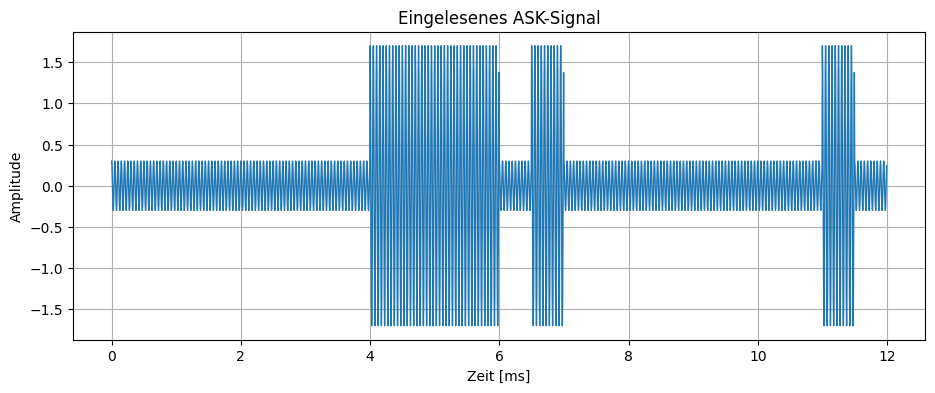

In [3]:
t_plot_ms = 12.0
n_plot = min(N_sig, int(t_plot_ms * 1e-3 * fs))

fig, ax = plt.subplots()
ax.plot(t[:n_plot] * 1e3, s_ask[:n_plot], lw=1.0)
ax.set_title('Eingelesenes ASK-Signal')
ax.set_xlabel('Zeit [ms]')
ax.set_ylabel('Amplitude')
plt.show()

## Schritt 1+2: Gleichrichtung + Sliding-Averager-Tiefpass

In [4]:
# Konfigurationsparameter:
# Tiefpass-Grenzfrequenz: oberhalb der Bitrate, deutlich unterhalb des Traegers
f_lp = 4.0 * R_b   # ungefaehre Grenzfrequenz [Hz]

x_rect = np.abs(s_ask)

N_win = max(3, int(round(fs / max(1.0, f_lp))))
if N_win % 2 == 0:
    N_win += 1

h_lp = np.ones(N_win, dtype=np.float64) / N_win
x_env = np.convolve(x_rect, h_lp, mode='same')

# Skalierung kompensiert den Mittelwert von |cos(.)| = 2/pi
x_env_scaled = (np.pi / 2.0) * x_env

print(f'Sliding-Averager: N_win = {N_win} Samples (f_lp ~ {f_lp:.0f} Hz)')
print(f'Erwartete Pegel der Huellkurve: 1 - m = {1-m:.3f},  1 + m = {1+m:.3f}')

Sliding-Averager: N_win = 25 Samples (f_lp ~ 8000 Hz)
Erwartete Pegel der Huellkurve: 1 - m = 0.300,  1 + m = 1.700


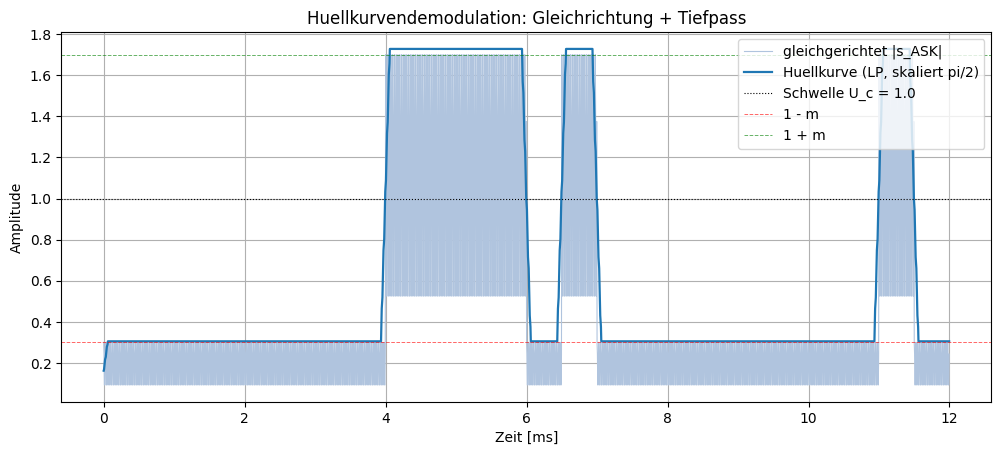

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(t[:n_plot] * 1e3, x_rect[:n_plot], color='lightsteelblue', lw=0.8,
        label='gleichgerichtet |s_ASK|')
ax.plot(t[:n_plot] * 1e3, x_env_scaled[:n_plot], lw=1.6,
        label='Huellkurve (LP, skaliert pi/2)')
ax.axhline(U_c, color='black', ls=':', lw=0.8, label=f'Schwelle U_c = {U_c}')
ax.axhline(U_c * (1 - m), color='red', ls='--', lw=0.7, alpha=0.6, label='1 - m')
ax.axhline(U_c * (1 + m), color='green', ls='--', lw=0.7, alpha=0.6, label='1 + m')
ax.set_title('Huellkurvendemodulation: Gleichrichtung + Tiefpass')
ax.set_xlabel('Zeit [ms]')
ax.set_ylabel('Amplitude')
ax.legend(loc='upper right')
plt.show()

## Schritt 3: Bitentscheidung (Mid-Bit-Sampling)

Wir tasten die Hüllkurve in der Mitte jedes Bitintervalls ab und vergleichen
mit der Schwelle $U_c$. Wegen der Gruppenlaufzeit des Sliding-Averager
(Filterlänge $N_{win}$) ist die Hüllkurve am Ausgang um $\lfloor N_{win}/2\rfloor$
Samples zentriert; bei `mode='same'` ist diese Verzögerung bereits
kompensiert.

In [6]:
sample_idx = (np.arange(n_bits) * samples_per_bit + samples_per_bit // 2)
sample_idx = np.clip(sample_idx, 0, N_sig - 1)
env_at_bit = x_env_scaled[sample_idx]
bits_demod = (env_at_bit > U_c).astype(np.int8)

n_err = int(np.sum(bits_demod != bits_orig))
ber = n_err / max(1, n_bits)
print(f'Bitfehler: {n_err} / {n_bits}  ->  BER = {ber:.3e}')
if n_err == 0:
    print('Alle Bits korrekt rekonstruiert.')

Bitfehler: 0 / 180  ->  BER = 0.000e+00
Alle Bits korrekt rekonstruiert.


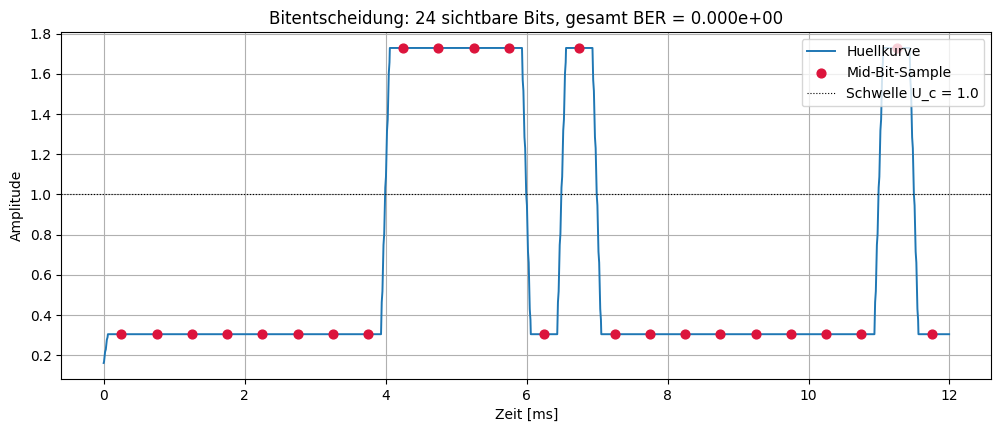

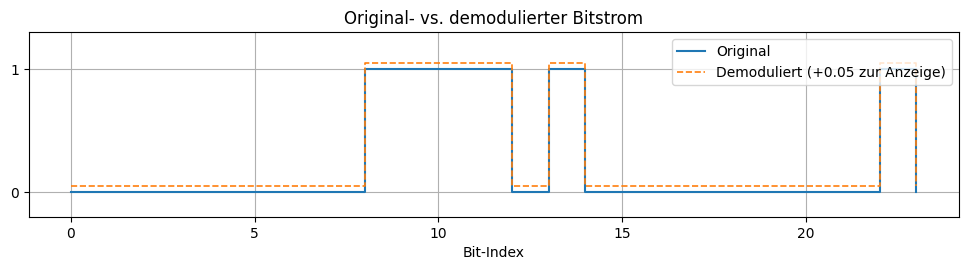

In [7]:
n_bits_plot = min(n_bits, n_plot // samples_per_bit)
if n_bits_plot < 1:
    n_bits_plot = 1
idx_plot = sample_idx[:n_bits_plot]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(t[:n_plot] * 1e3, x_env_scaled[:n_plot], lw=1.4, label='Huellkurve')
ax.scatter(t[idx_plot] * 1e3, x_env_scaled[idx_plot], s=40,
           color='crimson', zorder=4, label='Mid-Bit-Sample')
ax.axhline(U_c, color='black', ls=':', lw=0.8, label=f'Schwelle U_c = {U_c}')
ax.set_title(f'Bitentscheidung: {n_bits_plot} sichtbare Bits, gesamt BER = {ber:.3e}')
ax.set_xlabel('Zeit [ms]')
ax.set_ylabel('Amplitude')
ax.legend(loc='upper right')
plt.show()

fig, ax = plt.subplots(figsize=(12, 2.4))
ax.step(np.arange(n_bits_plot), bits_orig[:n_bits_plot], where='post',
        lw=1.5, label='Original')
ax.step(np.arange(n_bits_plot), bits_demod[:n_bits_plot] + 0.05, where='post',
        lw=1.2, ls='--', label='Demoduliert (+0.05 zur Anzeige)')
ax.set_ylim(-0.2, 1.3)
ax.set_yticks([0, 1])
ax.set_xlabel('Bit-Index')
ax.set_title('Original- vs. demodulierter Bitstrom')
ax.legend(loc='upper right')
plt.show()

## ToDo

- Beschreibe in eigenen Worten die mathematischen Funktionen dieser Signalverarbeitungs-Kette.
- Welche Aussagekraft haben die gezeigten Plots, was kann man daraus ableiten?